# Analisis Dataset Telco Customer: Memahami Pola Churn Pelanggan

**RISTEK Fasilkom UI - Sisters in Tech 2026**  
Portfolio Program | Machine Learning and Operations | Greycia Michelle

Dataset: IBM Telecom Customer Attrition Dataset


## 1. Alasan Pemilihan Dataset

Saya memilih dataset Telco Customer karena masalah churn pelanggan sangat relevan secara bisnis. Di industri telekomunikasi, biaya untuk mendapatkan pelanggan baru jauh lebih mahal dibandingkan mempertahankan yang sudah ada, sehingga kemampuan memprediksi pelanggan yang berpotensi pergi memiliki nilai praktis yang nyata.

Dataset ini juga menarik karena memiliki campuran fitur kategorikal dan numerik yang cukup kaya, mulai dari demografi, jenis layanan yang dilanggani, hingga pola pembayaran. Dengan kombinasi seperti ini, eksplorasi yang dilakukan tidak hanya soal distribusi angka-angka, tapi juga tentang bagaimana keputusan bisnis pelanggan terbentuk dari berbagai faktor yang saling berinteraksi.

Dari sisi MLOps, masalah ini juga relevan untuk latihan karena model churn di dunia nyata perlu di-deploy, dimonitor drift-nya (perilaku pelanggan bisa berubah seiring waktu), dan diperbarui secara berkala, yang merupakan inti dari siklus MLOps.


## 2. Eksplorasi Data

### 2.1 Setup & Import

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

RED_PALETTE = ['#ff2400', '#e61c04', '#ce1406', '#b50d07', '#9e0706', '#860204', '#700000']
RED_MAIN = '#ce1406'
RED_DARK = '#700000'
RED_LIGHT = '#ff2400'
RED_MED = '#b50d07'

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


### 2.2 Load & Profiling Awal

In [48]:
df = pd.read_csv('telco_cust_dataset.csv')

print(f"Dimensi dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
print("\nLima baris pertama:")
df.head()


Dimensi dataset: 7043 baris, 21 kolom

Lima baris pertama:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [49]:
print("Tipe data tiap kolom:")
print(df.dtypes)
print(f"\nTotal missing values per kolom:")
print(df.isnull().sum())
print(f"\nJumlah duplikat: {df.duplicated().sum()}")


Tipe data tiap kolom:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Total missing values per kolom:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract     

### 2.3 Diagnosis Kualitas Data

In [50]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

nan_rows = df[df['TotalCharges'].isnull()]
print(f"Jumlah baris dengan TotalCharges kosong setelah konversi: {len(nan_rows)}")
print("\nDetail baris bermasalah:")
print(nan_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].to_string(index=False))


Jumlah baris dengan TotalCharges kosong setelah konversi: 11

Detail baris bermasalah:
customerID  tenure  MonthlyCharges  TotalCharges
4472-LVYGI       0           52.55           NaN
3115-CZMZD       0           20.25           NaN
5709-LVOEQ       0           80.85           NaN
4367-NUYAO       0           25.75           NaN
1371-DWPAZ       0           56.05           NaN
7644-OMVMY       0           19.85           NaN
3213-VVOLG       0           25.35           NaN
2520-SGTTA       0           20.00           NaN
2923-ARZLG       0           19.70           NaN
4075-WKNIU       0           73.35           NaN
2775-SEFEE       0           61.90           NaN


In [51]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Missing values setelah penanganan:", df['TotalCharges'].isnull().sum())


Missing values setelah penanganan: 0


### 2.4 Statistik Deskriptif

In [52]:
print("Statistik deskriptif kolom numerik:")
df[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)


Statistik deskriptif kolom numerik:


,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


In [53]:
print("Distribusi variabel target:")
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True).round(4) * 100
summary = pd.DataFrame({'Jumlah': churn_counts, 'Persentase (%)': churn_pct})
print(summary)


Distribusi variabel target:
       Jumlah  Persentase (%)
Churn                        
No       5174           73.46
Yes      1869           26.54


### 2.5 Analisis Univariat

**Distribusi Target: Churn**

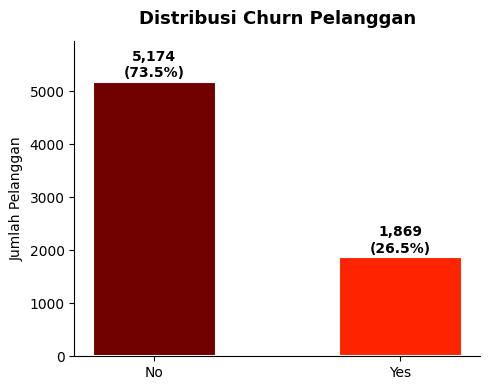

Rasio churn: 1 churned untuk setiap 2.8 pelanggan yang bertahan


In [54]:
fig, ax = plt.subplots(figsize=(5, 4))

churn_counts = df['Churn'].value_counts()
bars = ax.bar(churn_counts.index, churn_counts.values,
              color=[RED_DARK, RED_LIGHT], width=0.5, edgecolor='white', linewidth=1.5)

for bar, val in zip(bars, churn_counts.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribusi Churn Pelanggan', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Jumlah Pelanggan', fontsize=10)
ax.set_xlabel('')
ax.set_ylim(0, churn_counts.max() * 1.15)
ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

print(f"Rasio churn: 1 churned untuk setiap {round(churn_counts['No']/churn_counts['Yes'], 1)} pelanggan yang bertahan")


**Distribusi Variabel Numerik**

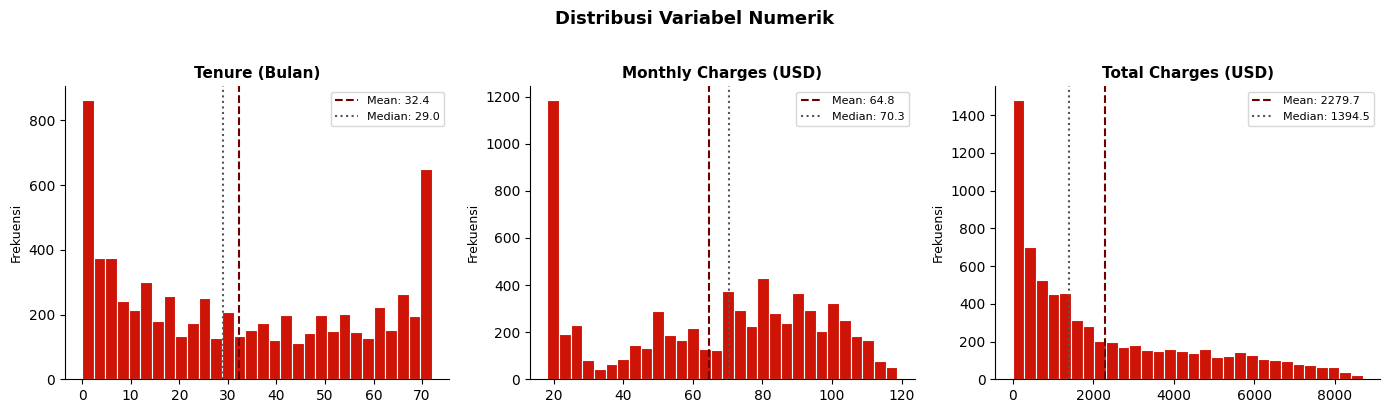

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
titles = ['Tenure (Bulan)', 'Monthly Charges (USD)', 'Total Charges (USD)']

for i, (col, title) in enumerate(zip(num_cols, titles)):
    ax = axes[i]
    ax.hist(df[col], bins=30, color=RED_MAIN, edgecolor='white', linewidth=0.8)

    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color=RED_DARK, linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    ax.axvline(median_val, color='#555555', linestyle=':', linewidth=1.5, label=f'Median: {median_val:.1f}')

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Frekuensi', fontsize=9)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Distribusi Variabel Numerik', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Distribusi Variabel Kategorik Utama**

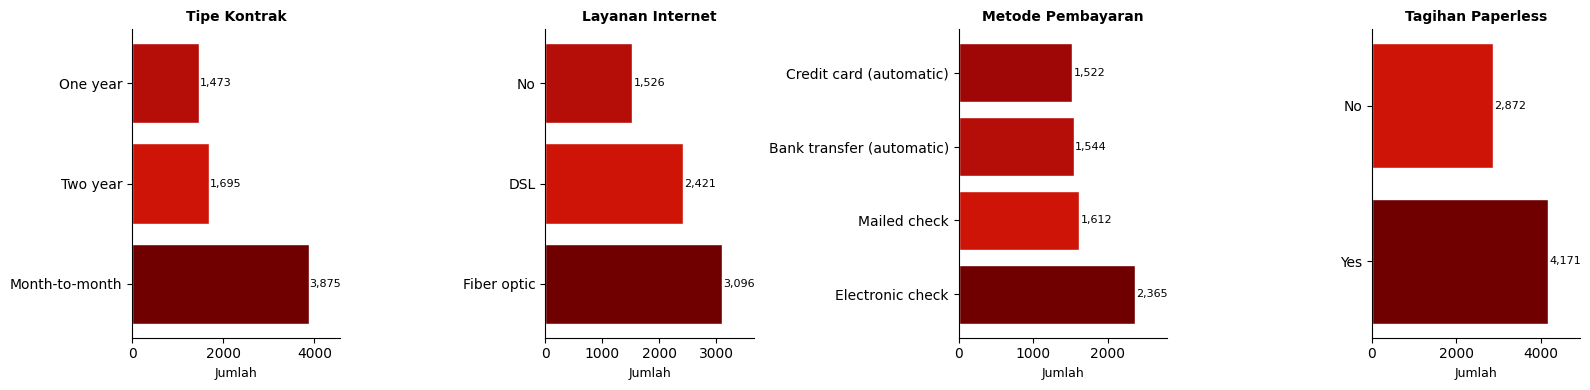

In [56]:
cat_main = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']
titles_cat = ['Tipe Kontrak', 'Layanan Internet', 'Metode Pembayaran', 'Tagihan Paperless']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, (col, title) in enumerate(zip(cat_main, titles_cat)):
    ax = axes[i]
    counts = df[col].value_counts()
    colors_bar = [RED_DARK if j == 0 else RED_PALETTE[j+1] for j in range(len(counts))]
    bars = ax.barh(counts.index, counts.values, color=colors_bar, edgecolor='white', linewidth=1)

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=8)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Jumlah', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(0, counts.max() * 1.18)

plt.tight_layout()
plt.show()


### 2.6 Analisis Bivariat

**Churn Rate per Tipe Kontrak & Layanan Internet**

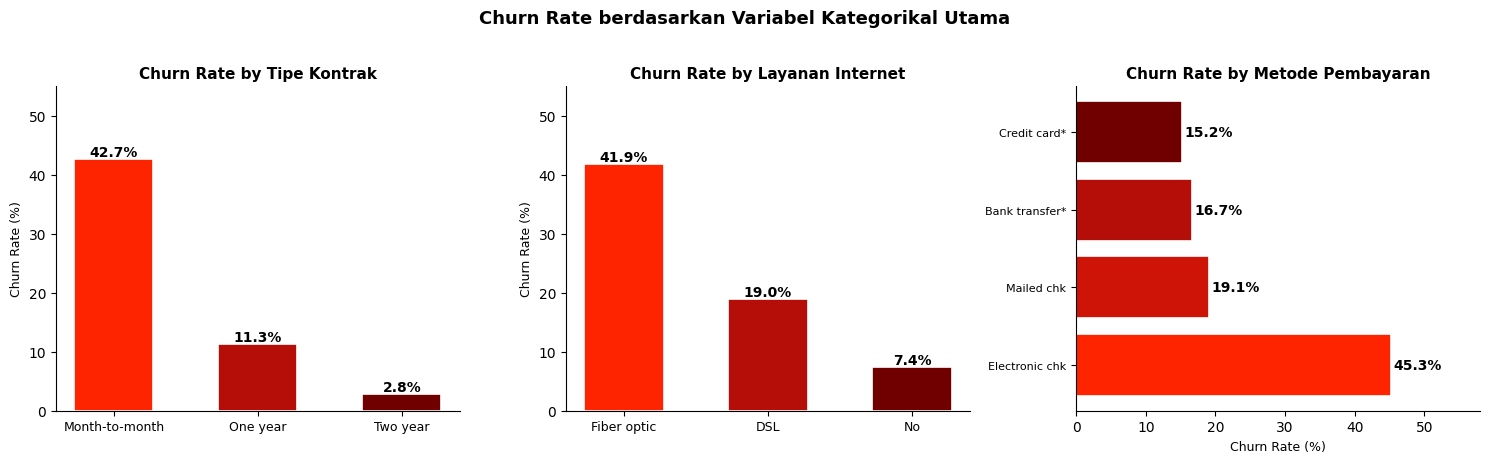

In [57]:
df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Contract
ax = axes[0]
contract_churn = df.groupby('Contract')['Churn_bin'].mean().sort_values(ascending=False)
bars = ax.bar(contract_churn.index, contract_churn.values * 100,
              color=[RED_LIGHT, RED_MED, RED_DARK][:len(contract_churn)],
              edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars, contract_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Churn Rate by Tipe Kontrak', fontsize=11, fontweight='bold')
ax.set_ylabel('Churn Rate (%)', fontsize=9)
ax.set_ylim(0, 55)
ax.tick_params(axis='x', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Internet Service
ax = axes[1]
inet_churn = df.groupby('InternetService')['Churn_bin'].mean().sort_values(ascending=False)
bars = ax.bar(inet_churn.index, inet_churn.values * 100,
              color=[RED_LIGHT, RED_MED, RED_DARK][:len(inet_churn)],
              edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars, inet_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Churn Rate by Layanan Internet', fontsize=11, fontweight='bold')
ax.set_ylabel('Churn Rate (%)', fontsize=9)
ax.set_ylim(0, 55)
ax.tick_params(axis='x', labelsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Payment Method
ax = axes[2]
pay_churn = df.groupby('PaymentMethod')['Churn_bin'].mean().sort_values(ascending=False)
labels_short = [p.replace(' (automatic)', '*').replace(' check', ' chk') for p in pay_churn.index]
bars = ax.barh(labels_short, pay_churn.values * 100,
               color=[RED_LIGHT, RED_PALETTE[2], RED_MED, RED_DARK],
               edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, pay_churn.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10, fontweight='bold')
ax.set_title('Churn Rate by Metode Pembayaran', fontsize=11, fontweight='bold')
ax.set_xlabel('Churn Rate (%)', fontsize=9)
ax.set_xlim(0, 58)
ax.tick_params(axis='y', labelsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.suptitle('Churn Rate berdasarkan Variabel Kategorikal Utama', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Distribusi Numerik: Churned vs Retained**

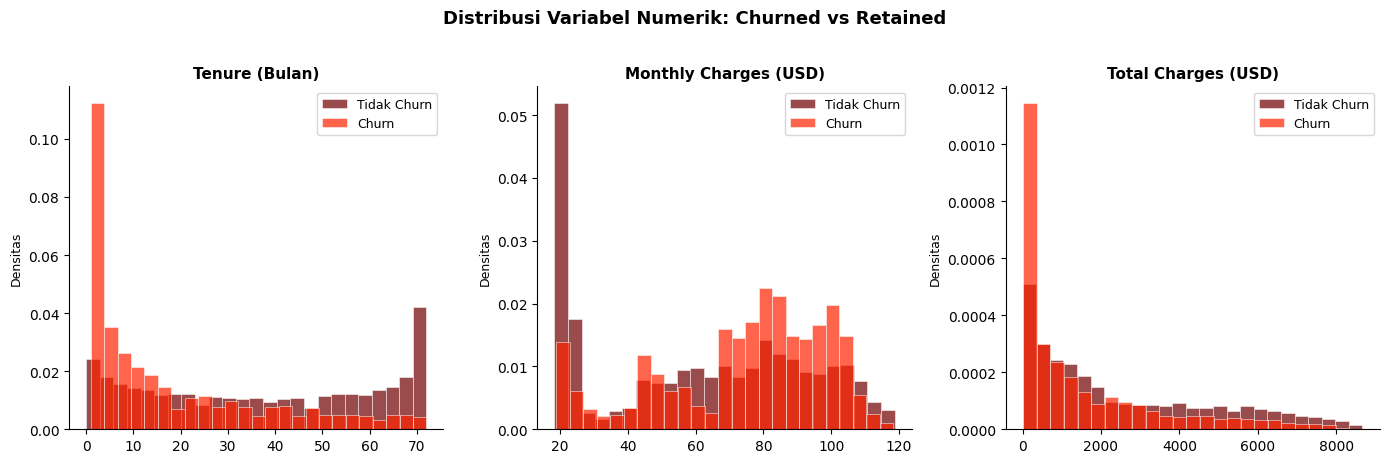

Rata-rata per grup:
       tenure  MonthlyCharges  TotalCharges
Churn                                      
No      37.57           61.27       2549.91
Yes     17.98           74.44       1531.80


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
titles = ['Tenure (Bulan)', 'Monthly Charges (USD)', 'Total Charges (USD)']

for i, (col, title) in enumerate(zip(num_cols, titles)):
    ax = axes[i]

    retained = df[df['Churn'] == 'No'][col]
    churned = df[df['Churn'] == 'Yes'][col]

    ax.hist(retained, bins=25, alpha=0.7, color=RED_DARK, label='Tidak Churn', density=True, edgecolor='white', linewidth=0.5)
    ax.hist(churned, bins=25, alpha=0.7, color=RED_LIGHT, label='Churn', density=True, edgecolor='white', linewidth=0.5)

    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Densitas', fontsize=9)
    ax.legend(fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Distribusi Variabel Numerik: Churned vs Retained', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("Rata-rata per grup:")
print(df.groupby('Churn')[['tenure','MonthlyCharges','TotalCharges']].mean().round(2))


**Layanan Tambahan vs Churn**

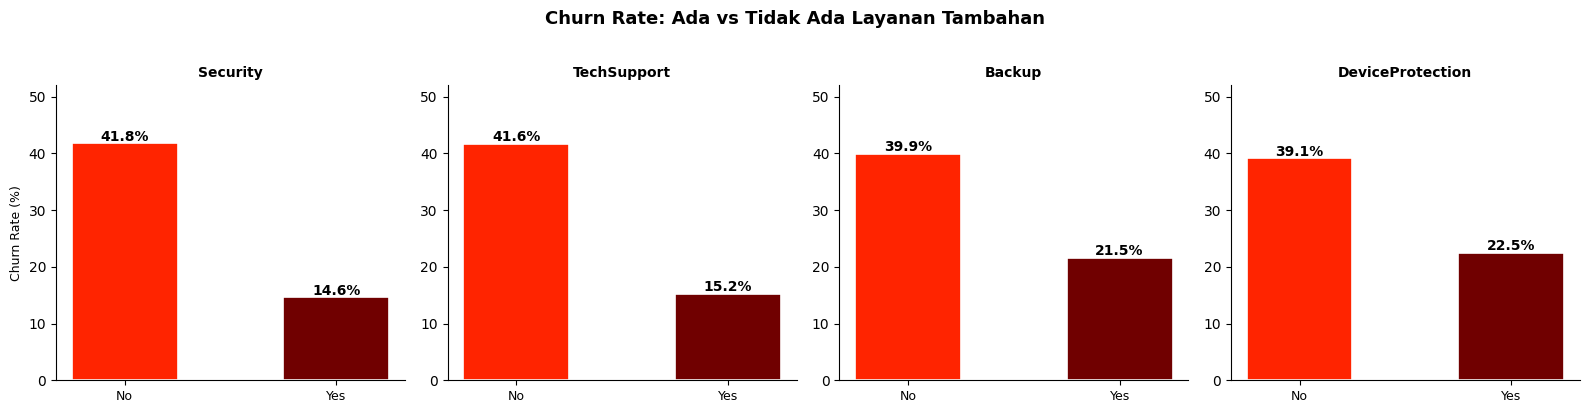

In [36]:
addon_services = ['OnlineSecurity', 'TechSupport', 'OnlineBackup', 'DeviceProtection']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, col in enumerate(addon_services):
    ax = axes[i]
    sub = df[df[col] != 'No internet service']
    churn_rates = sub.groupby(col)['Churn_bin'].mean() * 100

    color_map = {'No': RED_LIGHT, 'Yes': RED_DARK}
    bar_colors = [color_map.get(k, RED_MED) for k in churn_rates.index]

    bars = ax.bar(churn_rates.index, churn_rates.values, color=bar_colors,
                  edgecolor='white', linewidth=1.2, width=0.5)
    for bar, val in zip(bars, churn_rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

    ax.set_title(col.replace('Online', '').strip(), fontsize=10, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)' if i == 0 else '', fontsize=9)
    ax.set_ylim(0, 52)
    ax.tick_params(axis='x', labelsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Churn Rate: Ada vs Tidak Ada Layanan Tambahan', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 2.7 Analisis Multivariat

**Heatmap Korelasi Variabel Numerik**

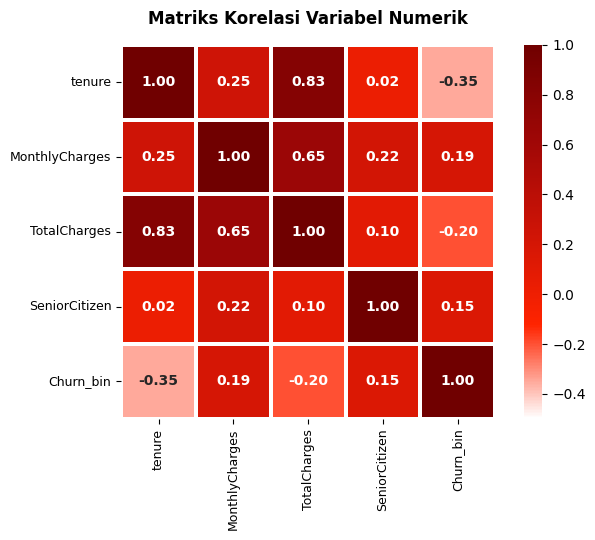

In [37]:
num_df = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_bin']].copy()
corr_matrix = num_df.corr()

fig, ax = plt.subplots(figsize=(7, 5.5))

cmap = sns.color_palette(['#ffffff', '#ff2400', '#ce1406', '#9e0706', '#700000'], as_cmap=True)
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = LinearSegmentedColormap.from_list('red_seq', ['#ffffff', '#ff2400', '#ce1406', '#9e0706', '#700000'])

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap=custom_cmap,
            ax=ax, linewidths=1.5, linecolor='white',
            vmin=-0.5, vmax=1, square=True,
            annot_kws={'size': 10, 'weight': 'bold'})

ax.set_title('Matriks Korelasi Variabel Numerik', fontsize=12, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.show()


**Churn Rate: Kontrak × Layanan Internet**

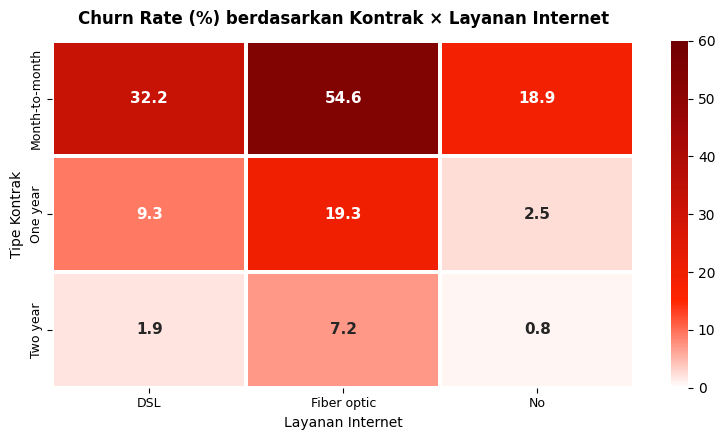

Interpretasi: Kombinasi Month-to-month + Fiber Optic adalah kombinasi paling berisiko (54.6% churn rate)


In [38]:
pivot = df.groupby(['Contract', 'InternetService'])['Churn_bin'].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))

custom_cmap2 = LinearSegmentedColormap.from_list('red_seq2', ['#ffffff', '#ff2400', '#ce1406', '#9e0706', '#700000'])
sns.heatmap(pivot, annot=True, fmt='.1f', cmap=custom_cmap2,
            ax=ax, linewidths=1.5, linecolor='white',
            vmin=0, vmax=60,
            annot_kws={'size': 11, 'weight': 'bold'})

ax.set_title('Churn Rate (%) berdasarkan Kontrak × Layanan Internet', fontsize=12, fontweight='bold', pad=12)
ax.set_xlabel('Layanan Internet', fontsize=10)
ax.set_ylabel('Tipe Kontrak', fontsize=10)
ax.tick_params(axis='both', labelsize=9)
plt.tight_layout()
plt.show()

print("Interpretasi: Kombinasi Month-to-month + Fiber Optic adalah kombinasi paling berisiko (54.6% churn rate)")


**Tenure vs Monthly Charges, diwarnai oleh Churn**

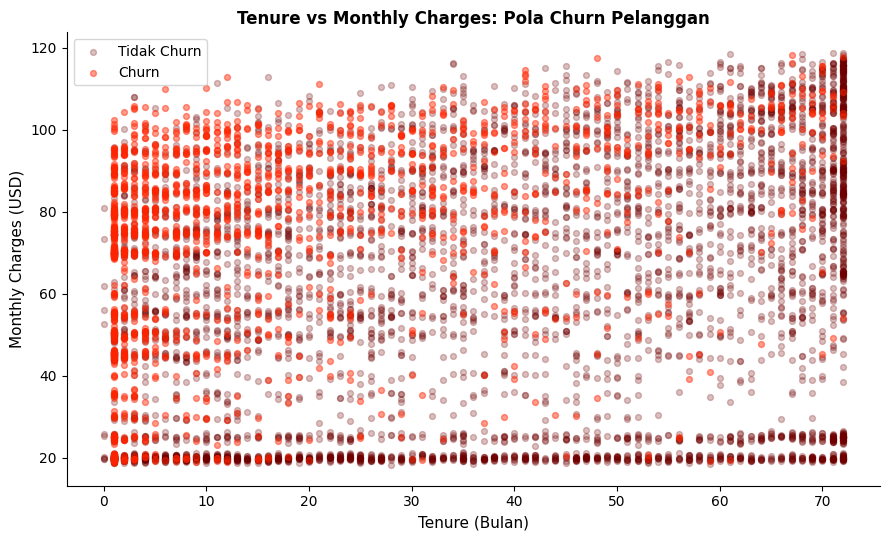

Pelanggan churn terkonsentrasi di tenure rendah dengan biaya menengah-tinggi


In [39]:
fig, ax = plt.subplots(figsize=(9, 5.5))

retained = df[df['Churn'] == 'No']
churned = df[df['Churn'] == 'Yes']

ax.scatter(retained['tenure'], retained['MonthlyCharges'],
           c=RED_DARK, alpha=0.25, s=18, label='Tidak Churn')
ax.scatter(churned['tenure'], churned['MonthlyCharges'],
           c=RED_LIGHT, alpha=0.45, s=18, label='Churn')

ax.set_xlabel('Tenure (Bulan)', fontsize=11)
ax.set_ylabel('Monthly Charges (USD)', fontsize=11)
ax.set_title('Tenure vs Monthly Charges: Pola Churn Pelanggan', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Pelanggan churn terkonsentrasi di tenure rendah dengan biaya menengah-tinggi")


## 3. Insights & Temuan Utama

Bagian ini menyajikan temuan-temuan paling menarik yang muncul dari eksplorasi data.


### 3.1 Profil Pelanggan yang Paling Berisiko Churn

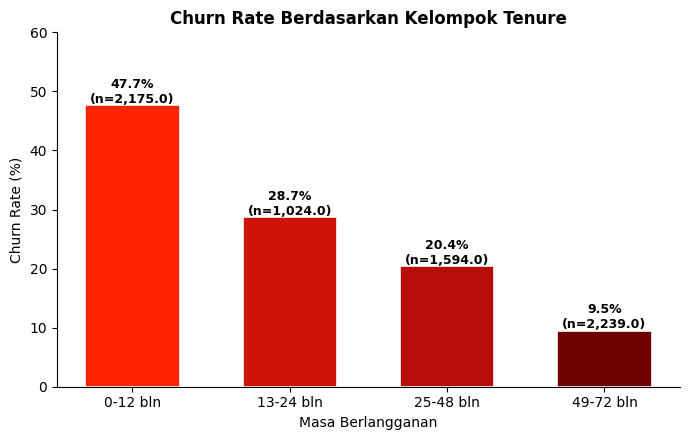

Pelanggan baru (0-12 bulan) hampir 5x lebih mungkin churn dibanding pelanggan lama (49-72 bulan)


In [40]:
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72],
                             labels=['0-12 bln', '13-24 bln', '25-48 bln', '49-72 bln'])

tenure_churn = df.groupby('tenure_group', observed=True)['Churn_bin'].agg(['mean', 'count'])
tenure_churn['mean_pct'] = tenure_churn['mean'] * 100

fig, ax = plt.subplots(figsize=(7, 4.5))

colors_ord = [RED_LIGHT, RED_PALETTE[2], RED_MED, RED_DARK]
bars = ax.bar(tenure_churn.index, tenure_churn['mean_pct'],
              color=colors_ord, edgecolor='white', linewidth=1.2, width=0.6)

for bar, (_, row) in zip(bars, tenure_churn.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f"{row['mean_pct']:.1f}%\n(n={row['count']:,})", ha='center', fontsize=9, fontweight='bold')

ax.set_title('Churn Rate Berdasarkan Kelompok Tenure', fontsize=12, fontweight='bold')
ax.set_xlabel('Masa Berlangganan', fontsize=10)
ax.set_ylabel('Churn Rate (%)', fontsize=10)
ax.set_ylim(0, 60)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Pelanggan baru (0-12 bulan) hampir 5x lebih mungkin churn dibanding pelanggan lama (49-72 bulan)")


### 3.2 Dampak Tipe Kontrak: Penentu Terbesar Churn

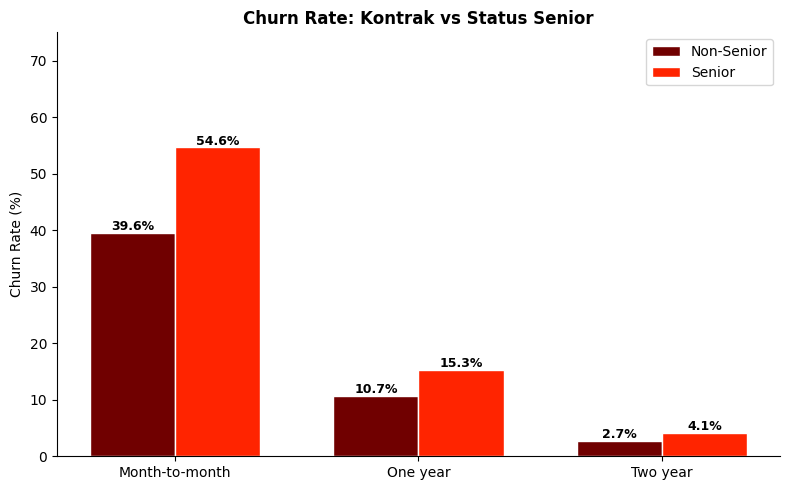

Pelanggan senior dengan kontrak month-to-month: churn rate paling tinggi di seluruh segmen
Senior + Month-to-month churn rate: 54.6%


In [41]:
cross = df.groupby(['Contract', 'SeniorCitizen'])['Churn_bin'].mean().unstack() * 100
cross.columns = ['Non-Senior', 'Senior']

x = np.arange(len(cross.index))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))

bars1 = ax.bar(x - width/2, cross['Non-Senior'], width, label='Non-Senior', color=RED_DARK, edgecolor='white')
bars2 = ax.bar(x + width/2, cross['Senior'], width, label='Senior', color=RED_LIGHT, edgecolor='white')

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(cross.index, fontsize=10)
ax.set_ylabel('Churn Rate (%)', fontsize=10)
ax.set_title('Churn Rate: Kontrak vs Status Senior', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.set_ylim(0, 75)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("Pelanggan senior dengan kontrak month-to-month: churn rate paling tinggi di seluruh segmen")
senior_mtm = df[(df['SeniorCitizen'] == 1) & (df['Contract'] == 'Month-to-month')]['Churn_bin'].mean()
print(f"Senior + Month-to-month churn rate: {senior_mtm:.1%}")


### 3.3 Electronic Check: Sinyal Ketidakpuasan?

Profil pengguna Electronic Check vs metode lain:
                           Electronic Check  Metode Lain
Churn Rate                            0.453        0.171
Rata-rata Tenure                     25.175       36.009
Rata-rata Monthly Charges            76.256       58.951
% Kontrak Bulanan                     0.782        0.433
% Fiber Optic                         0.674        0.321


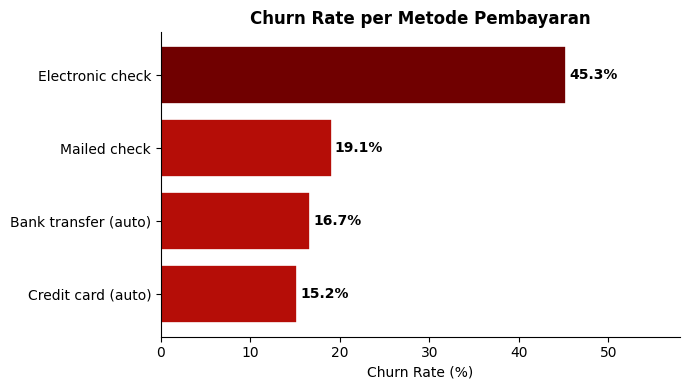

In [42]:
elec = df[df['PaymentMethod'] == 'Electronic check']
others = df[df['PaymentMethod'] != 'Electronic check']

print("Profil pengguna Electronic Check vs metode lain:")
comparison = pd.DataFrame({
    'Electronic Check': [
        elec['Churn_bin'].mean(),
        elec['tenure'].mean(),
        elec['MonthlyCharges'].mean(),
        (elec['Contract'] == 'Month-to-month').mean(),
        (elec['InternetService'] == 'Fiber optic').mean()
    ],
    'Metode Lain': [
        others['Churn_bin'].mean(),
        others['tenure'].mean(),
        others['MonthlyCharges'].mean(),
        (others['Contract'] == 'Month-to-month').mean(),
        (others['InternetService'] == 'Fiber optic').mean()
    ]
}, index=['Churn Rate', 'Rata-rata Tenure', 'Rata-rata Monthly Charges',
          '% Kontrak Bulanan', '% Fiber Optic'])

print(comparison.round(3))

fig, ax = plt.subplots(figsize=(7, 4))

pay_rates = df.groupby('PaymentMethod')['Churn_bin'].mean().sort_values(ascending=True) * 100
colors_pay = [RED_DARK if 'Electronic check' in p else RED_MED for p in pay_rates.index]
labels_pay = [p.replace(' (automatic)', ' (auto)') for p in pay_rates.index]

bars = ax.barh(labels_pay, pay_rates.values, color=colors_pay, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, pay_rates.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Churn Rate (%)', fontsize=10)
ax.set_title('Churn Rate per Metode Pembayaran', fontsize=12, fontweight='bold')
ax.set_xlim(0, 58)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


### 3.4 Pemodelan: Random Forest untuk Prediksi Churn

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

df_model = df.copy()
cat_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
            'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
            'PaperlessBilling', 'PaymentMethod']

for c in cat_cols:
    le = LabelEncoder()
    df_model[c] = le.fit_transform(df_model[c])

features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
            'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
            'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
            'MonthlyCharges', 'TotalCharges']

X = df_model[features]
y = df_model['Churn_bin']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("Performa Model:")
print(classification_report(y_test, y_pred, target_names=['Tidak Churn', 'Churn']))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")


Performa Model:
              precision    recall  f1-score   support

 Tidak Churn       0.82      0.90      0.86      1035
       Churn       0.63      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.77      0.78      0.77      1409

ROC-AUC Score: 0.8223


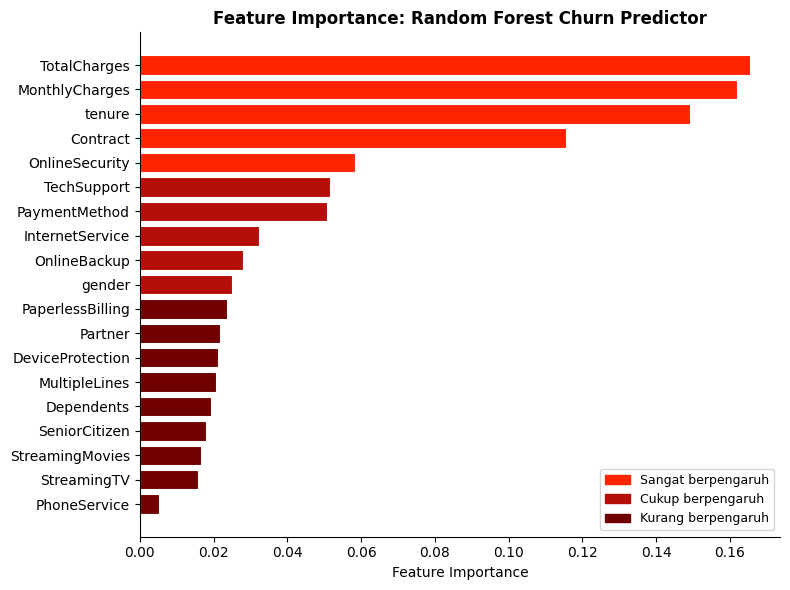

In [44]:
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))

colors_fi = []
top_threshold = feat_imp.sort_values(ascending=False).iloc[4]
for val in feat_imp.values:
    if val >= top_threshold:
        colors_fi.append(RED_LIGHT)
    elif val >= feat_imp.median():
        colors_fi.append(RED_MED)
    else:
        colors_fi.append(RED_DARK)

bars = ax.barh(feat_imp.index, feat_imp.values, color=colors_fi, edgecolor='white', linewidth=0.8)
ax.set_xlabel('Feature Importance', fontsize=10)
ax.set_title('Feature Importance: Random Forest Churn Predictor', fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_elements = [mpatches.Patch(color=RED_LIGHT, label='Sangat berpengaruh'),
                   mpatches.Patch(color=RED_MED, label='Cukup berpengaruh'),
                   mpatches.Patch(color=RED_DARK, label='Kurang berpengaruh')]
ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()


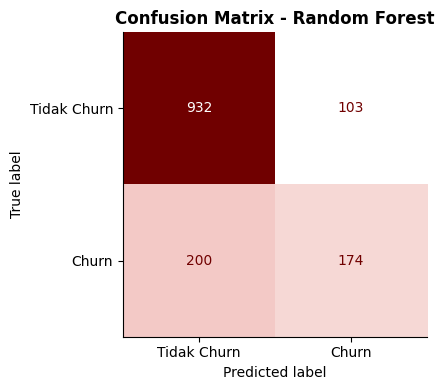

Akurasi keseluruhan: 78.5%
Dari 374 pelanggan yang benar-benar churn, model berhasil mendeteksi 174 (46.5%)


In [45]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred)

cmap_cm = LinearSegmentedColormap.from_list('red_cm', ['#ffffff', '#ce1406', '#700000'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Tidak Churn', 'Churn'])
disp.plot(ax=ax, cmap=cmap_cm, colorbar=False)

ax.set_title('Confusion Matrix - Random Forest', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

total = cm.sum()
print(f"Akurasi keseluruhan: {(cm[0,0]+cm[1,1])/total:.1%}")
print(f"Dari {cm[1,0]+cm[1,1]} pelanggan yang benar-benar churn, model berhasil mendeteksi {cm[1,1]} ({cm[1,1]/(cm[1,0]+cm[1,1]):.1%})")


### 3.5 Ringkasan Temuan Kunci

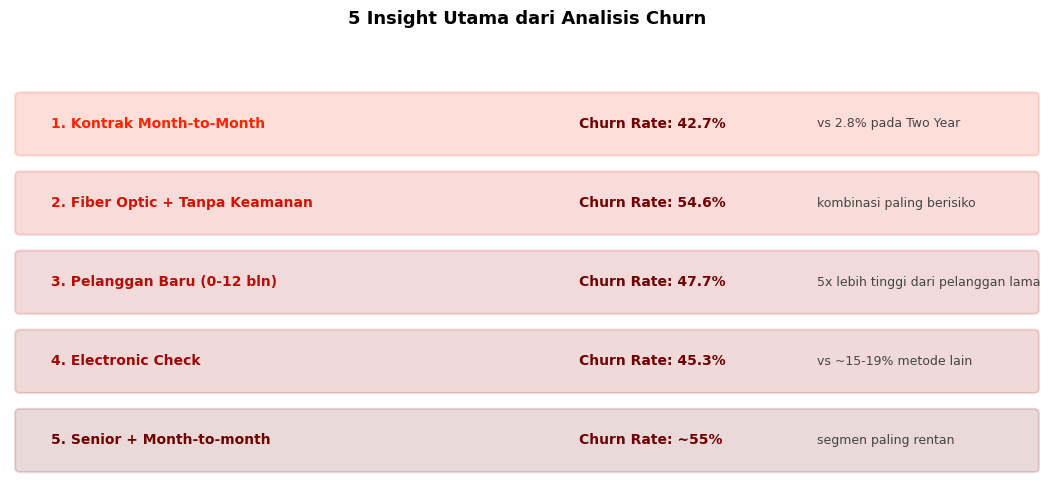

In [46]:
fig, ax = plt.subplots(figsize=(11, 5))

insights = [
    ('Kontrak Month-to-Month', '42.7%', 'vs 2.8% pada Two Year'),
    ('Fiber Optic + Tanpa Keamanan', '54.6%', 'kombinasi paling berisiko'),
    ('Pelanggan Baru (0-12 bln)', '47.7%', '5x lebih tinggi dari pelanggan lama'),
    ('Electronic Check', '45.3%', 'vs ~15-19% metode lain'),
    ('Senior + Month-to-month', '~55%', 'segmen paling rentan'),
]

ax.set_xlim(0, 10)
ax.set_ylim(0, len(insights) + 0.5)
ax.axis('off')
ax.set_title('5 Insight Utama dari Analisis Churn', fontsize=13, fontweight='bold', pad=15)

colors_insight = [RED_LIGHT, RED_PALETTE[2], RED_MED, RED_PALETTE[4], RED_DARK]

for i, (label, rate, desc) in enumerate(insights):
    y_pos = len(insights) - i - 0.5
    ax.add_patch(mpatches.FancyBboxPatch((0.1, y_pos - 0.35), 9.8, 0.7,
                                          boxstyle="round,pad=0.05",
                                          facecolor=colors_insight[i], alpha=0.15,
                                          edgecolor=colors_insight[i], linewidth=1.5))
    ax.text(0.4, y_pos, f'{i+1}. {label}', fontsize=10, fontweight='bold', va='center',
            color=colors_insight[i])
    ax.text(5.5, y_pos, f'Churn Rate: {rate}', fontsize=10, fontweight='bold', va='center',
            color=RED_DARK)
    ax.text(7.8, y_pos, desc, fontsize=9, va='center', color='#444444')

plt.tight_layout()
plt.show()


## 4. Refleksi

### Proses Kerja

Saya mulai dengan membaca struktur dataset sebelum menulis satu baris kode pun. Dari situ langsung ketahuan ada anomali kecil: kolom `TotalCharges` yang seharusnya numerik ternyata tersimpan sebagai string. Setelah dicek, 11 baris punya nilai kosong karena `tenure = 0`, bukan error sungguhan, jadi saya isi dengan 0.

Urutan analisis saya ikuti dari yang paling dasar dulu: profiling, kualitas data, baru eksplorasi visual. Awalnya saya coba langsung bivariate tapi terasa ada yang hilang karena belum tahu distribusi masing-masing variabel terlebih dahulu. Setelah balik ke univariat, pemahaman untuk tahap selanjutnya jadi lebih solid.

Untuk modeling, saya pilih Random Forest karena bisa langsung memberikan feature importance tanpa perlu preprocessing yang rumit untuk data campuran seperti ini. Hasilnya cukup informatif: tiga fitur teratas (TotalCharges, MonthlyCharges, tenure) semuanya berkaitan dengan durasi dan nilai ekonomis pelanggan.

### Keterbatasan

Kelas churn tidak seimbang (26.5% vs 73.5%), dan saya hanya menggunakan `class_weight='balanced'` sebagai kompensasi. Di kondisi nyata, teknik seperti SMOTE atau threshold tuning lebih tepat untuk kasus seperti ini.

Analisis ini juga sepenuhnya bersifat cross-sectional, tidak ada informasi waktu. Saya tidak bisa tahu apakah perilaku churn berubah dari bulan ke bulan, padahal di MLOps hal itu penting untuk memonitor data drift.

Selain itu, beberapa fitur layanan punya kategori "No internet service" yang dicampur dengan "No" saat encoding. Di iterasi berikutnya, kategori ini sebaiknya dipisahkan atau dikelompokkan ulang agar tidak menimbulkan noise di model.

### Apa yang Bisa Dikembangkan

Yang paling menarik untuk dieksplor selanjutnya adalah membangun pipeline yang lebih lengkap: mulai dari preprocessing yang lebih ketat, eksperimen dengan model lain (XGBoost, Logistic Regression), evaluasi dengan metrik yang lebih tepat seperti F1 untuk kelas minoritas, sampai simulasi deployment menggunakan FastAPI untuk model serving.

Dari sisi MLOps yang sebenarnya, monitoring konsep drift juga penting untuk dataset seperti ini karena perilaku pelanggan telekomunikasi cukup dinamis dan bisa berubah signifikan dalam beberapa kuartal.
